In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

CNN CBAM

In [77]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

In [78]:
EXTRACT_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_MAP = {c:i for i,c in enumerate(CLASS_NAMES)}

IMG_SIZE = 128

In [79]:
def get_all_images(root_dir):
    exts = ('*.png','*.jpg','*.jpeg','*.bmp','*.tif')
    image_paths = []

    for ext in exts:
        image_paths.extend(
            glob.glob(os.path.join(root_dir, '**', ext), recursive=True)
        )

    return image_paths

images = get_all_images(EXTRACT_DIR)

print("Total images found:", len(images))
print("Sample paths:", images[:3])

Total images found: 7200
Sample paths: ['/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg', '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg', '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg']


In [80]:
def load_and_preprocess_for_cnn(image_paths, img_size=(128,128)):

    X, y = [], []

    for path in image_paths:

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Normalize
        img = img.astype(np.float32) / 255.0

        # Median filter
        img_med = cv2.medianBlur((img * 255).astype(np.uint8), 3)
        img_med = img_med.astype(np.float32) / 255.0

        # Resize
        img_med = cv2.resize(img_med, img_size)

        # Expand channel
        img_med = np.expand_dims(img_med, axis=-1)

        X.append(img_med)

        # ---- Correct label from folder ----
        for cls in CLASS_NAMES:
            if cls in path.lower():
                y.append(CLASS_MAP[cls])
                break

    X = np.array(X)
    y = to_categorical(np.array(y), num_classes=len(CLASS_NAMES))

    return X, y

In [81]:
print("\nPreparing data for CNN...")

X, y = load_and_preprocess_for_cnn(images, (IMG_SIZE, IMG_SIZE))

# shuffle (VERY IMPORTANT)
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Preparing data for CNN...
Training samples: (5760, 128, 128, 1)
Testing samples: (1440, 128, 128, 1)


In [82]:
def cbam_block(feature_map, ratio=8):

    channel = feature_map.shape[-1]

    avg_pool = GlobalAveragePooling2D()(feature_map)
    avg_pool = Dense(channel//ratio, activation='relu')(avg_pool)
    avg_pool = Dense(channel, activation='sigmoid')(avg_pool)
    avg_pool = Reshape((1,1,channel))(avg_pool)

    max_pool = GlobalMaxPooling2D()(feature_map)
    max_pool = Dense(channel//ratio, activation='relu')(max_pool)
    max_pool = Dense(channel, activation='sigmoid')(max_pool)
    max_pool = Reshape((1,1,channel))(max_pool)

    channel_attention = Add()([avg_pool, max_pool])
    x = Multiply()([feature_map, channel_attention])

    avg_sp = Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_sp = Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_sp, max_sp])
    spatial = Conv2D(1,7,padding='same',activation='sigmoid')(concat)

    return Multiply()([x, spatial])

In [83]:
def build_cnn_cbam(input_shape):

    inputs = Input(shape=input_shape)

    x = Conv2D(32,3,activation='relu')(inputs)
    x = MaxPooling2D()(x)

    x = Conv2D(64,3,activation='relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128,3,activation='relu')(x)
    x = MaxPooling2D()(x)

    x = cbam_block(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(len(CLASS_NAMES), activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [89]:
model = build_cnn_cbam(X_train.shape[1:])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=45,
    batch_size=16
)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 126, 126,  │        320 │ input_layer_18[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_36    │ (None, 63, 63,    │          0 │ conv2d_42[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 61, 61,    │     18,496 │ max_pooling2d_36… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_37    │ (None, 30, 30,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 28, 28,    │     73,856 │ max_pooling2d_37… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_38    │ (None, 14, 14,    │          0 │ conv2d_44[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_38… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ max_pooling2d_38… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 16)        │      2,064 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 128)       │      2,176 │ dense_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 128)       │      2,176 │ dense_54[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_21          │ (None, 1, 1, 128) │          0 │ dense_53[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_22          │ (None, 1, 1, 128) │          0 │ dense_55[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 1, 1, 128) │          0 │ reshape_21[0][0], │
│                     │                   │            │ reshape_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 14, 14,    │          0 │ max_pooling2d_38… │
│ (Multiply)          │ 128)              │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 14, 14, 1) │          0 │ multiply_15[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,313,159 (12.64 MB)

 Trainable params: 3,313,159 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4790 - loss: 1.1411 - val_accuracy: 0.7410 - val_loss: 0.6972
Epoch 2/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7284 - loss: 0.7074 - val_accuracy: 0.7701 - val_loss: 0.5702
Epoch 3/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7728 - loss: 0.5915 - val_accuracy: 0.8333 - val_loss: 0.4709
Epoch 4/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8224 - loss: 0.4861 - val_accuracy: 0.8562 - val_loss: 0.4135
Epoch 5/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8456 - loss: 0.4145 - val_accuracy: 0.8597 - val_loss: 0.3929
Epoch 6/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8671 - loss: 0.3697 - val_accuracy: 0.8833 - val_loss: 0.3347
Epoch 7/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8684 - loss: 0.3341 - val_accuracy: 0.8833 - val_loss: 0.3289
Epoch 8/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8854 - loss: 0.2968 - val_accuracy: 0

In [90]:
preds = model.predict(X_test)

y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')

print("\n===== FINAL METRICS =====")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("F2 Score :", f2)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

===== FINAL METRICS =====
Accuracy : 0.9548611111111112
Precision: 0.9565195906777705
Recall   : 0.9548611111111112
F1 Score : 0.9547967929966303
F2 Score : 0.9546255443250241

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.88      0.93       344
  meningioma       0.89      0.96      0.93       356
     notumor       0.97      0.99      0.98       359
   pituitary       0.99      0.98      0.98       381

    accuracy                           0.95      1440
   macro avg       0.96      0.95      0.95      1440
weighted avg       0.96      0.95      0.95      1440



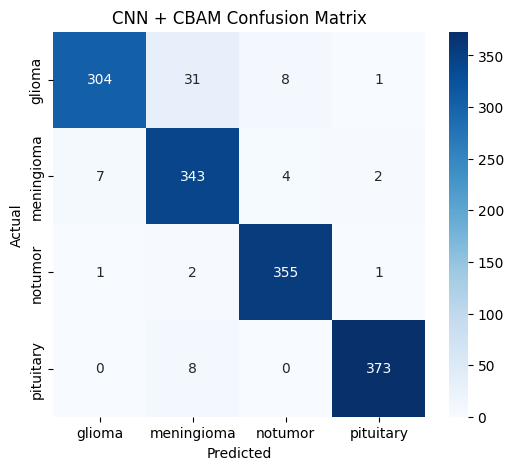

In [91]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")

plt.title("CNN + CBAM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [92]:
results = {}

results["CNN_CBAM"] = {
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "F2": f2
}

df_results = pd.DataFrame(results).T
df_results.to_csv("cnn_cbam_results.csv")

df_results

,Accuracy,Precision,Recall,F1,F2
CNN_CBAM,0.954861,0.95652,0.954861,0.954797,0.954626


CNN Attention

In [100]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import numpy as np
import cv2
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

In [101]:
EXTRACT_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

CLASS_NAMES = ['glioma','meningioma','notumor','pituitary']
CLASS_MAP = {c:i for i,c in enumerate(CLASS_NAMES)}

IMG_SIZE = 128
BATCH_SIZE = 16

In [102]:
def load_and_preprocess_for_cnn(image_paths, img_size=(128,128)):

    X, y = [], []

    for path in image_paths:

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # normalize
        img = img.astype(np.float32)/255.0

        # median filter (your requirement)
        img_med = cv2.medianBlur((img*255).astype(np.uint8),3)
        img_med = img_med.astype(np.float32)/255.0

        img_med = cv2.resize(img_med, img_size)
        img_med = np.expand_dims(img_med, axis=-1)

        X.append(img_med)

        # correct class extraction
        for cls in CLASS_NAMES:
            if cls in path.lower():
                y.append(CLASS_MAP[cls])
                break

    X = np.array(X)
    y = to_categorical(np.array(y), num_classes=len(CLASS_NAMES))

    return X, y

In [103]:
print("Preparing dataset...")

X, y = load_and_preprocess_for_cnn(images, (IMG_SIZE,IMG_SIZE))

idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Preparing dataset...
Train: (5760, 128, 128, 1)
Test : (1440, 128, 128, 1)


In [104]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

datagen.fit(X_train)

In [106]:
def mhsa_block(x, num_heads=4):

    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]

    seq = Reshape((h*w, c))(x)
    seq = LayerNormalization()(seq)

    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=c//num_heads
    )(seq, seq)

    seq = Add()([seq, attn])

    out = Reshape((h, w, c))(seq)

    return out

In [107]:
def build_cnn_mhsa(input_shape):

    inputs = tf.keras.Input(shape=input_shape)

    x = Conv2D(32,3,activation='relu')(inputs)
    x = MaxPooling2D()(x)

    x = Conv2D(64,3,activation='relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128,3,activation='relu')(x)
    x = MaxPooling2D()(x)

    # Transformer Attention
    x = mhsa_block(x, num_heads=4)

    x = Flatten()(x)
    x = Dense(128,activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(len(CLASS_NAMES),activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [109]:
model = build_cnn_mhsa(X_train.shape[1:])
model.summary()

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=45
)

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 126, 126,  │        320 │ input_layer_20[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_42    │ (None, 63, 63,    │          0 │ conv2d_49[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 61, 61,    │     18,496 │ max_pooling2d_42… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_43    │ (None, 30, 30,    │          0 │ conv2d_50[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 28, 28,    │     73,856 │ max_pooling2d_43… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_44    │ (None, 14, 14,    │          0 │ conv2d_51[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_25          │ (None, 196, 128)  │          0 │ max_pooling2d_44… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 128)  │        256 │ reshape_25[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 196, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_26          │ (None, 14, 14,    │          0 │ add_11[0][0]      │
│ (Reshape)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 25088)     │          0 │ reshape_26[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 128)       │  3,211,392 │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 128)       │          0 │ dense_60[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 4)         │        516 │ dropout_18[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,370,884 (12.86 MB)

 Trainable params: 3,370,884 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4178 - loss: 1.3031 - val_accuracy: 0.6889 - val_loss: 0.7899
Epoch 2/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6610 - loss: 0.8321 - val_accuracy: 0.7688 - val_loss: 0.5907
Epoch 3/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7160 - loss: 0.7141 - val_accuracy: 0.7958 - val_loss: 0.5197
Epoch 4/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7591 - loss: 0.6242 - val_accuracy: 0.8056 - val_loss: 0.5059
Epoch 5/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7608 - loss: 0.5944 - val_accuracy: 0.7569 - val_loss: 0.5940
Epoch 6/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7895 - loss: 0.5323 - val_accuracy: 0.8264 - val_loss: 0.4530
Epoch 7/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8015 - loss: 0.5100 - val_accuracy: 0.8389 - val_loss: 0.4160
Epoch 8/45
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8061 - loss: 0.4962 - val_acc

In [110]:
preds = model.predict(X_test)

y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')

print("\n===== CNN + MHSA RESULTS =====")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("F2 Score :", f2)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

===== CNN + MHSA RESULTS =====
Accuracy : 0.9666666666666667
Precision: 0.9665784758750375
Recall   : 0.9666666666666667
F1 Score : 0.9665399957113234
F2 Score : 0.9665964715568347

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.96      0.96       384
  meningioma       0.96      0.93      0.94       348
     notumor       0.97      0.99      0.98       363
   pituitary       0.99      0.99      0.99       345

    accuracy                           0.97      1440
   macro avg       0.97      0.97      0.97      1440
weighted avg       0.97      0.97      0.97      1440



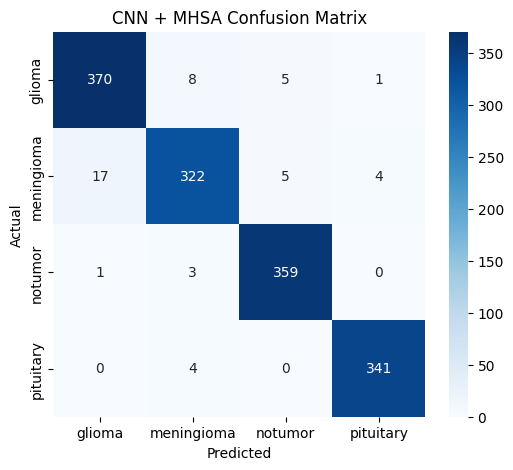

In [111]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")

plt.title("CNN + MHSA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [112]:
results_mhsa = {
    "CNN_MHSA": {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2
    }
}

df = pd.DataFrame(results_mhsa).T
df.to_csv("cnn_mhsa_results.csv")

df

,Accuracy,Precision,Recall,F1,F2
CNN_MHSA,0.966667,0.966578,0.966667,0.96654,0.966596


Lenet

In [113]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU Name: Tesla P100-PCIE-16GB
Total GPU Memory: 17.1 GB


In [118]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

In [119]:
filtered_dir = "/kaggle/input/datasets/adityaudai/brain2-filtered/brain2_filtered"

train_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomRotation(12),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.08,0.08)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [120]:
train_dataset = datasets.ImageFolder(
    os.path.join(filtered_dir,"Training"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(filtered_dir,"Testing"),
    transform=test_transform
)

class_names = train_dataset.classes

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)

test_loader = DataLoader(test_dataset,
                         batch_size=32,
                         shuffle=False,
                         num_workers=2,
                         pin_memory=True)

print("Classes:", class_names)
print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5712
Test : 1311


In [121]:
class LeNetPlus(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(64*8*8, 256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,num_classes)

    def forward(self,x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = torch.flatten(x,1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        return self.fc3(x)

model = LeNetPlus(len(class_names)).to(device)
print(model)

LeNetPlus(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)


In [122]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.3
)

scaler = GradScaler()

/tmp/ipykernel_55/2472474959.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


MobileNet

In [140]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

In [154]:
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

train_dir = f"{DATASET_PATH}/Training"
test_dir  = f"{DATASET_PATH}/Testing"

IMG_SIZE = 224
BATCH_SIZE = 32

In [155]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [156]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

In [157]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
])

In [158]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Phase 1: freeze backbone
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [159]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [160]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
        mode="max"
    )
]

In [161]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.7346 - loss: 0.8233 - val_accuracy: 0.7912 - val_loss: 0.5953 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8659 - loss: 0.3708 - val_accuracy: 0.7981 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8886 - loss: 0.3000 - val_accuracy: 0.8050 - val_loss: 0.7310 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9173 - loss: 0.2418 - val_accuracy: 0.8181 - val_loss: 0.7976 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9109 - loss: 0.2267 - val_accuracy: 0.8250 - val_loss: 0.7499 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9291 - loss: 0.1878 - val_accuracy: 0.8375 - val_loss: 0.7019 - learning_rate: 0.0010
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9327 - loss: 0

In [162]:
base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [163]:
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [164]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [165]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.9614 - loss: 0.1059 - val_accuracy: 0.8706 - val_loss: 0.7479 - learning_rate: 1.0000e-05
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9675 - loss: 0.0846 - val_accuracy: 0.8712 - val_loss: 0.7913 - learning_rate: 1.0000e-05
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9709 - loss: 0.0852 - val_accuracy: 0.8544 - val_loss: 0.8358 - learning_rate: 1.0000e-05
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9690 - loss: 0.0847 - val_accuracy: 0.8737 - val_loss: 0.7184 - learning_rate: 1.0000e-05
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9729 - loss: 0.0787 - val_accuracy: 0.8781 - val_loss: 0.6579 - learning_rate: 1.0000e-05
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9725 - loss: 0.0695 - val_accuracy: 0.8625 - val_loss: 0.8090 - learning_rate: 1.0000e-05
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - ac

In [166]:
y_true = np.concatenate([y for x, y in val_ds], axis=0)

preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')

print("\n===== MobileNetV2 RESULTS =====")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("F2 Score :", f2)

print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step

===== MobileNetV2 RESULTS =====
Accuracy : 0.893125
Precision: 0.9018280822054525
Recall   : 0.893125
F1 Score : 0.8896085454925557
F2 Score : 0.8901762866023057
              precision    recall  f1-score   support

      glioma       0.99      0.69      0.82       400
  meningioma       0.81      0.89      0.85       400
     notumor       0.93      0.99      0.96       400
   pituitary       0.88      0.99      0.93       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



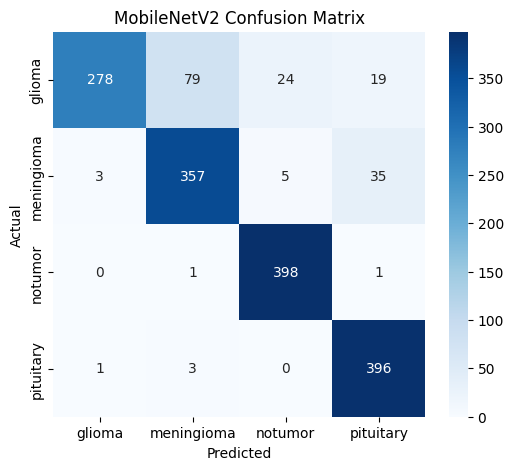

In [167]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

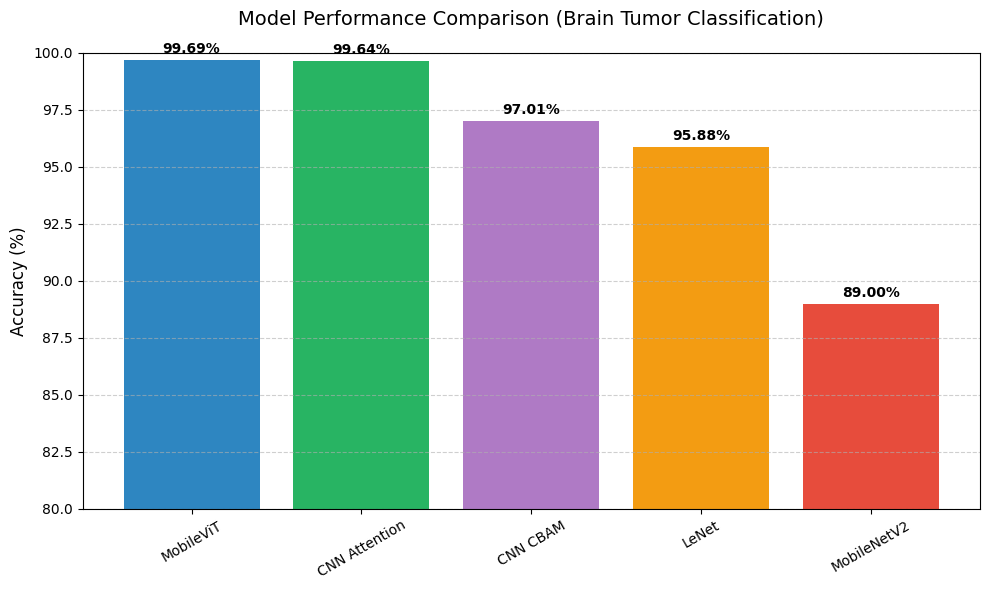

In [169]:
import matplotlib.pyplot as plt

# Data
models = [
    "MobileViT",
    "CNN Attention",
    "CNN CBAM",
    "LeNet",
    "MobileNetV2"
]

accuracies = [
    99.69,
    99.64,
    97.01,
    95.88,
    89.00
]

# Create figure
plt.figure(figsize=(10,6))

colors = ["#2E86C1", "#28B463", "#AF7AC5", "#F39C12", "#E74C3C"]
bars = plt.bar(models, accuracies, color=colors)

# Add accuracy labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(80, 100)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Performance Comparison (Brain Tumor Classification)", fontsize=14,pad=20)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()